# SQRT (Sub-zero Quantitative Research Team)

## Post-Heat Test Data Analysis

**Authors:** Caimin Keavney, Bruce Ritter

I have added some code to analyze our heat data and figure out how long it will take us to run out of heat based on environmental temp.
I think the fitting done below works, using Newtons law of cooling. plz double check tho. -BR, 13/4.

This code uses code from Caimin Keaveney's post-mission data anlysis code to do the following: 

The processes applied below will extract, translate and store all relevant mission data acquired by the SQRT mission. This data will be in the form of both transmitted data and data stored onboard the SD card. Depending on which of these modes is relevant, (recovery dependent) two workflows will be required to unload the data products.

### Onboard Storage (SD card)

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from array import array

In [10]:
# The folder container all of the SD card is defined. 

def science_data_proc(datafile):
    """
    Extracts and cleans Science Data from MLX90640.
    """
    times = []
    frame_arrays = []
    with open(datafile, "r") as f:
        # The data is unloaded from the file
        data = f.readlines()[1:]

    # The times and data are stored in two separate lists.
    for line in data:
        if len(line) < 1000:
            time = line.split()[0]
            times.append(time)
        else:
            
            values = line.strip().split(",")  
            frame_arrays.append([float(v) for v in values if v != ""])

    return times, frame_arrays


def house_proc(housefile):
    """
    Extracts and stores Housekeeping Data from sensors
    """
    Housekeeping_Data = {
        "Times": [],
        "Internal_Temperature": [],
        "External_Temperature": [],
        "Pressure": [],
        "Latitudes": [],
        "Longitudes": [],
        "Altitudes": [],
        "HDOP": []
    }

    with open(housefile, "r") as f:
        lines = f.readlines()[1:]

    
    for line in lines:
        items = line.strip().split(",")
        
        if len(items) == 10:
            Housekeeping_Data["Times"].append(items[0])
            Housekeeping_Data["Pressure"].append(items[2])
            Housekeeping_Data["External_Temperature"].append(items[3])
            Housekeeping_Data["Internal_Temperature"].append(items[4])
            Housekeeping_Data["Latitudes"].append(items[5])
            Housekeeping_Data["Longitudes"].append(items[6])
            Housekeeping_Data["Altitudes"].append(items[7])
            Housekeeping_Data["HDOP"].append(items[8])
        else:
            continue

    return Housekeeping_Data
    

    
def error_proc(error_file):
    """
    Extracts and stores Error Log
    """
    error_dict = {
        "Times": [],
        "Error": [],
        "Sensor/Class": []
    }

    with open(error_file, "r") as f:
        lines = f.readlines()[1:]

    for line in lines:
        items = line.strip().split(",")
        if len(items) == 3:     
            error_dict["Times"].append(items[0])
            error_dict["Error"].append(items[1])
            error_dict["Sensor/Class"].append(items[2])
        else:
            continue
    
    return error_dict

def trig_proc(trig_file):
    """
    Extracts and stores Trigger file information (trigger statuses & trigger conditions if applicable).
    """

    trig_dic = {
        "time": [],
        "trig_statuses": [],
        "trig_conditions": [],
        "trig_pressures": [],
        "trig_altitudes": []
    }

    with open(trig_file, "r") as f:
        lines = f.readlines()[1:]

    for line in lines:
        items = line.strip().split(",")
        if len(items) ==5:
            trig_dic["time"].append(items[0])
            trig_dic["trig_statuses"].append(items[1])
            trig_dic["trig_conditions"].append(items[2])
            trig_dic["trig_pressures"].append(items[3])
            trig_dic["trig_altitudes"].append(items[4])
        else:
            continue
        
    return trig_dic


def sd_processor(folder_path):
    files = os.listdir(folder_path)

    # Returns are initialised in case no files are present.
    t = d = t_s = d_s = None
    house_dict = error_dict = trig_dict = None
    
    for file in files:
        fullpath = folder_path + "/" + file
        
        if "data" in file:
            if "trigger" in file:
                t_s, d_s = science_data_proc(fullpath)
            else:
                t, d = science_data_proc(fullpath)


        elif "housekeeping" in file:
            house_dict = house_proc(fullpath)

        elif "error" in file:
            error_dict = error_proc(fullpath)

        elif "trigger_log" in file: 
            trig_dict = trig_proc(fullpath)

        else: 
            continue
    return house_dict, error_dict, trig_dict, (t_s,d_s), (t,d)

### Transmitted Data Packets Analysis

In [11]:
all_house_data = []
all_science_data = []


def packet_proc(textfile):
    """
    Deals with all packets 
    """
    with open(textfile, "r") as f:
        packets = f.readlines()

    for packet in packets:
        packet= packet.strip()
        
        items = packet.split("|")

        
        if items[1].strip() == "SQRT":
            packet_type = items[0].strip()[-1]
            
            if packet_type == "T":
                all_house_data.append(packet)    # Telemetry Packet
                
            elif packet_type == "D":
                all_science_data.append(packet)   # Science Packet

        else:
            continue
    house_info = house_packet_parser(all_house_data)
    frames, science_info = science_packet_parser(all_science_data)

    decoded_frames = frames_proc(frames)
    
    return house_info, science_info, decoded_frames

def house_packet_parser(packets):
    """
    Parses data from received data packets and stores/ housekeeping/science data
    """
    house_data = {
        "timestamp": [],
        "pressure": [],
        "external_temp": [],
        "internal_temp": [],
        "latitude": [],
        "longitude": [],
        "altitude": [],
        "hdop": [],
        "error_count": [],
        "error_types": []
    }
    
    for packet in packets:
        
        items = packet.split("|")
        
        if len(items)<14:
            continue
            
        house_data["timestamp"].append(items[4])
        house_data["gps_times"].append(items[5])
        house_data["latitude"].append(items[6])
        house_data["longitude"].append(items[7])
        house_data["hdop"].append(items[7])
        house_data["altitude"].append(items[8])
        house_data["internal_temp"].append(items[9])
        house_data["external_temp"].append(items[10])
        house_data["pressure"].append(items[11])
        house_data["error_count"].append(items[12])
        house_data["error_types"].append(items[13])


    return house_data

def science_packet_parser(packets):
    """
    Handles Science data packets including frame data, which is sent to save_data and saved 
    """
    frames_data = []

    trig_dic = {
        "trig": [],
        "condition": [],
        "pres": [],
        "alt": []
    }

    for packet in packets:
        items = packet.split("|")

        frames_data.append(items[2])
        trig_dic["trig"].append(items[3])
        trig_dic["condition"].append(items[4])
        trig_dic["pres"].append(items[5])
        trig_dic["alt"].append(items[6])

    return frames_data, trig_dic
    
def frames_proc(frames_list):
    """
    Processes frame data, which is in binary format
    """
    frames = []
    for frame in frames_list:
        arr = array('h')
        arr.frombytes(bytes.fromhex(frame))
        decoded_frame = [x/100 for x in arr]
        
        frames.append(decoded_frame)

        
    return frames

In [12]:
fridge_hk, fridge_error, fridge_trig, science, normal = sd_processor("fridge_test_6/")




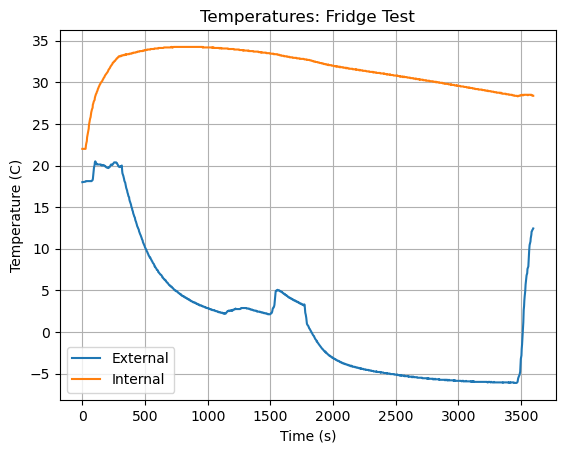

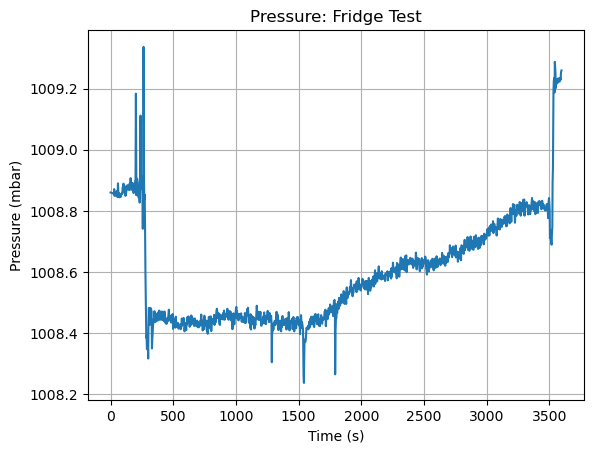

In [13]:





import numpy as np
import matplotlib.pyplot as plt

# External temperature
TE = fridge_hk["External_Temperature"][1:]  # skip header
tsE = fridge_hk["Times"][1:]

# Clean data (remove None / "None" / " None")
clean_TE = []
clean_tsE = []

for t, ts_val in zip(TE, tsE):
    if t not in [None, "None", " None", ""]:
        clean_TE.append(float(t))
        clean_tsE.append(int(ts_val))
    else: 
        clean_TE.append(0)
        clean_tsE.append(int(ts_val))

TE = np.array(clean_TE)
tsE = np.array(clean_tsE)

# Internal temperature
clean_TI = []
clean_tsI = []

TI_raw = fridge_hk["Internal_Temperature"][1:]
ts_raw = fridge_hk["Times"][1:]


for t, ts_val in zip(TI_raw, ts_raw):
    if t not in [None, "None", " None", ""]:
        clean_TI.append(float(t))
        clean_tsI.append(float(ts_val))
    else:
        clean_TI.append(0)
        clean_tsI.append(float(ts_val))

TI = np.array(clean_TI)
tsI = np.array(clean_tsI)
# Pressure
P = np.array(fridge_hk["Pressure"][1:], dtype=float)

# Time
ts = np.array(fridge_hk["Times"][1:], dtype=float)

ts_elapsed = ts - ts[0]
tsE_elapsed = tsE - tsE[0]
tsI_elapsed = tsI - tsI[0]


# ---- Plotting ----
plt.plot(tsE_elapsed,TE, label="External")
plt.plot(tsI_elapsed, TI, label="Internal")
plt.title("Temperatures: Fridge Test")

plt.xlabel("Time (s)")
plt.ylabel("Temperature (C)")
plt.grid()
plt.legend()
plt.savefig("Fridge_Test")
plt.show()

plt.plot(ts_elapsed, P)
plt.title("Pressure: Fridge Test")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (mbar)")
plt.savefig("Pressure Test")
plt.grid()
plt.show()









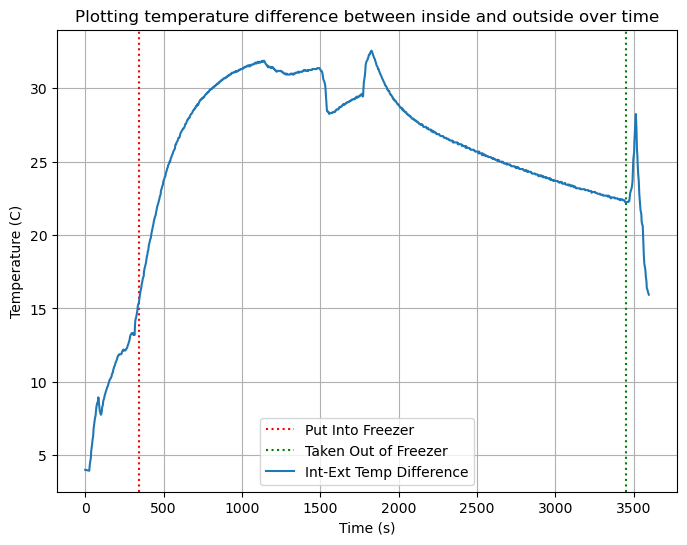

In [39]:
fig, ax = plt.subplots(figsize = (8, 6))

ax.set_title("Plotting temperature difference between inside and outside over time")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Temperature (C)")

plt.axvline(x = 340, ls = ":", color = "r", label = "Put Into Freezer")
plt.axvline(x = 3450, ls = ":", color = "g", label = "Taken Out of Freezer" )

ax.plot(tsI_elapsed, [np.abs(np.abs(TE[i]) - np.abs(TI[i])) for i in range(len(TE))], label = "Int-Ext Temp Difference")

plt.grid()
plt.legend()

In [15]:
from scipy.optimize import curve_fit

def temp_decay(t, T_0, T_env, h):
    """
    Newtons law of cooling function, but moved around so I can use it to fit to the exponential 
    temp decay that happens when the sat is in the freezer and the environmental temp has 
    dropped off
    Inputs: 
    T_0 = initial temperature (put it the intial temp when decay starts)
    T_env = environmental temperature (ext temps)
    h = heat transfer coefficient
    t = time
    """
    return (T_0 - T_env) * np.exp(-h * t) + T_env


def fit_decay(T_list, T_env_list, times):
    """
    function to fit the exponent to our data
    Inputs:
    T_list: list of temps
    T_env_list: list of environmental temps
    times: list of times
    
    Output: 
    curvefit popt and pcov lists
    """

    T_0 = T_list[0]
    T_env = T_env_list[-1]
    h_guess = 1 / (times[-1] - times[0])

    p0 = [T_0, T_env, h_guess]

    popt, pcov = curve_fit(temp_decay, times, T_list, p0 = p0, maxfev=10000)

    return popt, pcov


In [17]:
# fitting the data with the newtons cooling law studd above
popt, pcov = fit_decay(TI[500:3000], TE[500:3000], tsI_elapsed[500:3000])
print(popt)

time_fit = np.linspace(0, 3500, 10000)
T_fit = temp_decay(time_fit, *popt)

[3.82958770e+01 1.29630144e+01 1.41101478e-04]


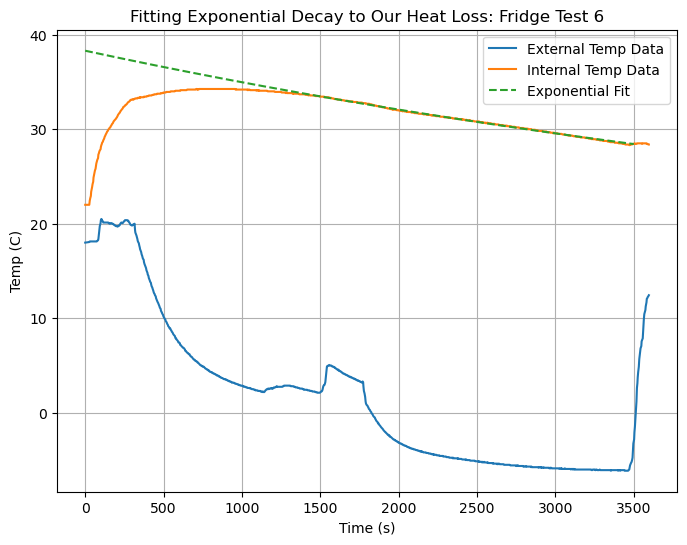

In [18]:
# plotting fit and data: 

plt.close("all")
fig, ax = plt.subplots(figsize = (8,6))
ax.set_title("Fitting Exponential Decay to Our Heat Loss: Fridge Test 6")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Temp (C)")

ax.plot(tsE_elapsed,TE, label="External Temp Data")
ax.plot(tsI_elapsed, TI, label="Internal Temp Data")

ax.plot(time_fit, T_fit, ls = "--", label = "Exponential Fit")

plt.grid()
plt.legend()
plt.show()

In [19]:
# my results: 

print("Eq for the fit:")
print(f"T(t) = ({popt[0]:.2f} - {popt[1]:.2f})e^(- {popt[2]} * t) + {popt[1]:.2f}")

Eq for the fit:
T(t) = (38.30 - 12.96)e^(- 0.00014110147773061996 * t) + 12.96


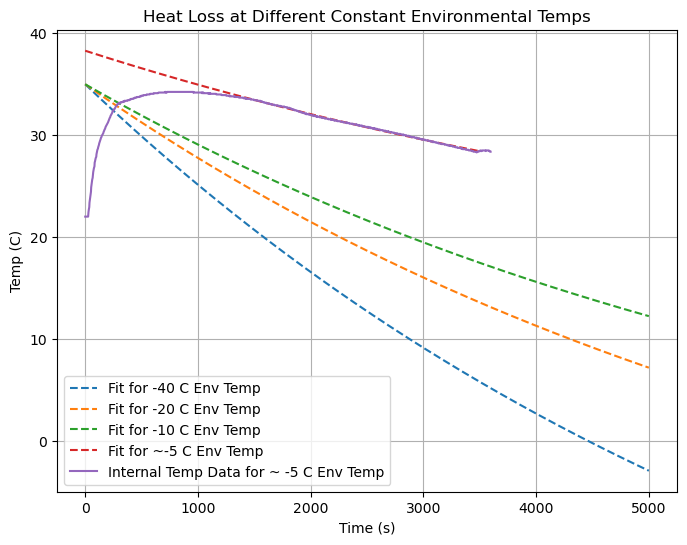

In [41]:
# what if T_env is -40 degrees not an average of 12? then what does the decay look like?

h = popt[2]

time_fit40 = np.linspace(0, 5000, 10000)
T_fit40 = temp_decay(time_fit40, 35, -40, h)

time_fit20 = np.linspace(0, 5000, 10000)
T_fit20 = temp_decay(time_fit20, 35, -20, h)

time_fit10 = np.linspace(0, 5000, 10000)
T_fit10 = temp_decay(time_fit10, 35, -10, h)


# plotting fits and data: 

plt.close("all")
fig, ax = plt.subplots(figsize = (8,6))
ax.set_title("Heat Loss at Different Constant Environmental Temps")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Temp (C)")

ax.plot(time_fit40, T_fit40, ls = "--", label = "Fit for -40 C Env Temp")
ax.plot(time_fit20, T_fit20, ls = "--", label = "Fit for -20 C Env Temp")
ax.plot(time_fit10, T_fit10, ls = "--", label = "Fit for -10 C Env Temp")

ax.plot(time_fit, T_fit, ls = "--", label = "Fit for ~-5 C Env Temp")

ax.plot(tsI_elapsed, TI, label="Internal Temp Data for ~ -5 C Env Temp")

plt.grid()
plt.legend()
plt.show()


In [29]:
#not sure why the start of the fit is lower than the data other than ig because environmental temp is lower?

In [42]:
for sec, T in zip(time_fit40, T_fit40):
    if T <= 25:
        t_25_40 = sec
        break
for sec, T in zip(time_fit40, T_fit40):
    if T <= 20:
        t_20_40 = sec
        break
for sec, T in zip(time_fit40, T_fit40):   
    if T <= 0:
        t_0_40 = sec
        break
for sec, T in zip(time_fit10, T_fit10):
    if T <= 25:
        t_25_10 = sec
        break
for sec, T in zip(time_fit10, T_fit10):
    if T <= 20:
        t_20_10 = sec
        break
#for sec, T in zip(time_fit10, T_fit10):   
    #if T <= 0:
        #t_0_10 = sec
        #break

# assuming -40 degrees environmental temp the whole way:

print(f"0 C: We'll reach 25 deg C at {t_25_10 / 60:.2f} min, 20 deg C at {t_20_10 / 60:.2f} min.")

print(f"-40 C: We'll reach 25 deg C at {t_25_40 / 60:.2f} min, 20 deg C at {t_20_40 / 60:.2f} min, and 0 deg at {t_0_40 /60:.2f} min or {t_0_40} sec.")


0 C: We'll reach 25 deg C at 29.69 min, 20 deg C at 47.90 min.
-40 C: We'll reach 25 deg C at 16.91 min, 20 deg C at 26.36 min, and 0 deg at 74.26 min or 4455.445544554455 sec.


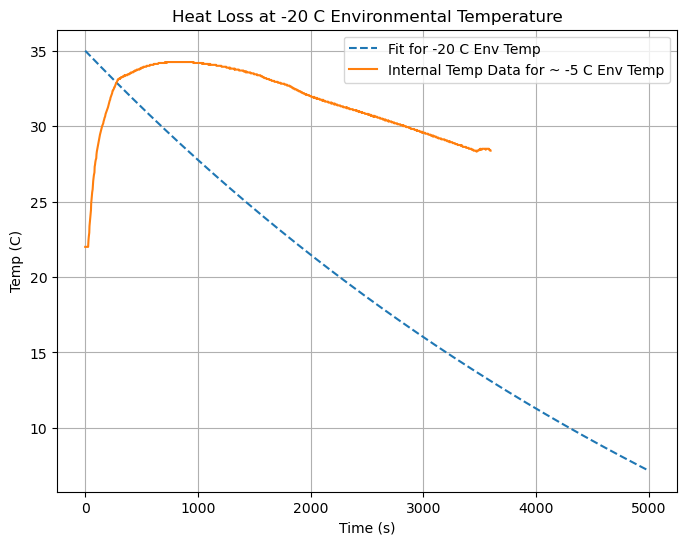

In [87]:
h = popt[2]

time_fit = np.linspace(0, 5000, 10000)
T_fit = temp_decay(time_fit, 35, -20, h)

# plotting fit and data: 

plt.close("all")
fig, ax = plt.subplots(figsize = (8,6))
ax.set_title("Heat Loss at -20 C Environmental Temperature")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Temp (C)")

ax.plot(time_fit, T_fit, ls = "--", label = "Fit for -20 C Env Temp")
ax.plot(tsI_elapsed, TI, label="Internal Temp Data for ~ -5 C Env Temp")

plt.grid()
plt.legend()
plt.show()


In [16]:
def save_frames(frames, out_dir, times=None):
    """
    frames: list of decoded frames (list of floats)
    """
    os.makedirs(out_dir, exist_ok=True) 

    fig, ax = plt.subplots()
    
    for i, frame in enumerate(frames):
        ax.clear()
    
        frame = np.array(frame)
    
        if len(frame) == 768:
            shaped = frame.reshape(24, 32)
        elif len(frame) == 48:
            shaped = frame.reshape(6, 8)
        else:
            continue
    
        heatmap = ax.imshow(shaped, cmap="YlGnBu", origin="upper", vmin=-10, vmax = 50)
    
        label = times[i] if times is not None else f"frame_{i}"
        safe_label = str(label).replace(":", "_")
    
        ax.set_title(f"{label}")
    
        filename = os.path.join(out_dir, f"frame_{i:04d}.png")
        plt.savefig(filename, dpi=100, bbox_inches="tight")
    
    plt.close(fig)

In [17]:
save_frames(f_bt[1], "fridge_frames", f_bt[0])

NameError: name 'f_bt' is not defined

In [2]:
import imageio.v2 as imageio
import cv2
import os

folder = "fridge_frames"
images = sorted(os.listdir(folder))

writer = imageio.get_writer(
    "timelapse.mp4",
    fps=20,
    codec="libx264"   # this is the key for PowerPoint
)

for img in images:
    path = os.path.join(folder, img)
    frame = cv2.imread(path)

    if frame is None:
        continue

    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    writer.append_data(frame)

writer.close()

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (540, 433) to (544, 448) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
